In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cv2

from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [44]:
columns = [
    'center',
    'left',
    'right',
    'steering',
    'throttle',
    'brake',
    'speed'
]

df = pd.read_csv(
    'driving_log.csv',
    names=columns
)

df = df.dropna()

df['steering'] = df['steering'].astype(float)
df['speed'] = df['speed'].astype(float)

print("Dataset shape:", df.shape)

df.head()


Dataset shape: (3875, 7)


,center,left,right,steering,throttle,brake,speed
0,D:\ML Projects\Deep Learning\Self Drive\IMG\ce...,D:\ML Projects\Deep Learning\Self Drive\IMG\le...,D:\ML Projects\Deep Learning\Self Drive\IMG\ri...,0.0,0.000000,0.0,8.830345e-07
1,D:\ML Projects\Deep Learning\Self Drive\IMG\ce...,D:\ML Projects\Deep Learning\Self Drive\IMG\le...,D:\ML Projects\Deep Learning\Self Drive\IMG\ri...,0.0,0.000000,0.0,1.518825e-05
2,D:\ML Projects\Deep Learning\Self Drive\IMG\ce...,D:\ML Projects\Deep Learning\Self Drive\IMG\le...,D:\ML Projects\Deep Learning\Self Drive\IMG\ri...,0.0,0.000000,0.0,1.364254e-05
3,D:\ML Projects\Deep Learning\Self Drive\IMG\ce...,D:\ML Projects\Deep Learning\Self Drive\IMG\le...,D:\ML Projects\Deep Learning\Self Drive\IMG\ri...,0.0,0.384953,0.0,6.311529e-01
4,D:\ML Projects\Deep Learning\Self Drive\IMG\ce...,D:\ML Projects\Deep Learning\Self Drive\IMG\le...,D:\ML Projects\Deep Learning\Self Drive\IMG\ri...,-0.5,1.000000,0.0,2.968876e+00


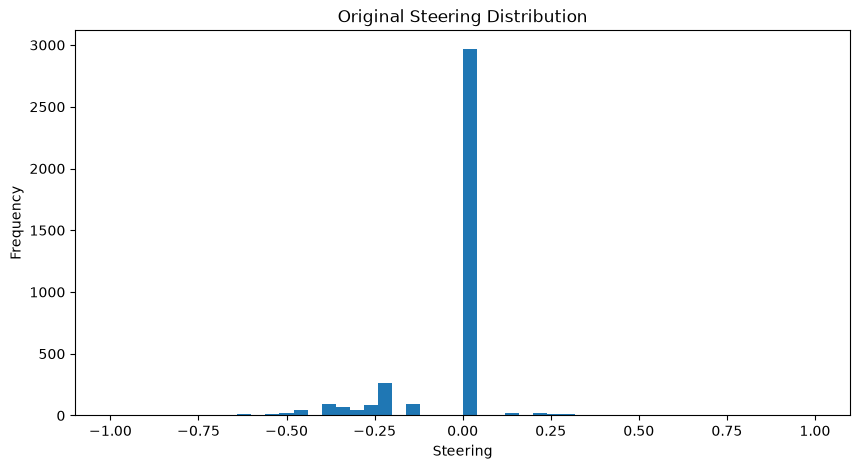

In [45]:
plt.figure(figsize=(10, 5))

plt.hist(
    df['steering'],
    bins=50
)

plt.title('Original Steering Distribution')
plt.xlabel('Steering')
plt.ylabel('Frequency')

plt.show()


In [46]:
df['steering'].describe()

count    3875.000000
mean       -0.049755
std         0.163742
min        -1.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: steering, dtype: float64

In [47]:
def preprocess_image(img):
    img = img[60:135, :, :]
    img = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    img = cv2.GaussianBlur(img, (3, 3), 0)
    img = cv2.resize(img, (200, 66))
    img = img / 255.0

    return img


In [48]:
def augment_flip(image, steering):
    if np.random.rand() < 0.5:
        image = cv2.flip(image, 1)
        steering = -steering

    return image, steering


In [49]:
def augment_brightness(image):
    hsv = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2HSV
    ).astype(np.float32)

    ratio = np.random.uniform(0.65, 1.35)

    hsv[:, :, 2] *= ratio
    hsv[:, :, 2] = np.clip(
        hsv[:, :, 2],
        0,
        255
    )

    return cv2.cvtColor(
        hsv.astype(np.uint8),
        cv2.COLOR_HSV2RGB
    )

def augment_translation(image, steering):
    if np.random.rand() < 0.5:

        height, width = image.shape[:2]

        shift = np.random.randint(-30, 31)

        translation = np.float32([
            [1, 0, shift],
            [0, 1, 0]
        ])

        image = cv2.warpAffine(
            image,
            translation,
            (width, height),
            borderMode=cv2.BORDER_REPLICATE
        )

        steering += shift / 30.0 * 0.12

    return image, steering


In [50]:
df['steering'] = df['steering'].clip(-1.0, 1.0)

df['steering_bin'] = pd.cut(
    df['steering'],
    bins=[
        -1.01,
        -0.40,
        -0.25,
        -0.15,
        -0.05,
        0.05,
        0.15,
        0.25,
        0.40,
        1.01
    ],
    labels=False,
    include_lowest=True
)

bin_counts = df['steering_bin'].value_counts().sort_index()

print("Bin counts:")
print(bin_counts)

bin_weights = 1.0 / bin_counts

df['sample_weight'] = df['steering_bin'].map(bin_weights)

df['sample_weight'] = (
    df['sample_weight']
    .fillna(1.0)
    .clip(0.5, 4.0)
)

df['sample_weight'] = (
    df['sample_weight'] /
    df['sample_weight'].mean()
)

print("\nNaN weights:", df['sample_weight'].isna().sum())
print("Min weight:", df['sample_weight'].min())
print("Max weight:", df['sample_weight'].max())

df[['steering', 'steering_bin', 'sample_weight']].head(10)

Bin counts:
steering_bin
0     218
1     196
2     359
3       4
4    2969
5      28
6      40
7      26
8      35
Name: count, dtype: int64

NaN weights: 0
Min weight: 1.0
Max weight: 1.0


,steering,steering_bin,sample_weight
0,0.00,4,1.0
1,0.00,4,1.0
2,0.00,4,1.0
3,0.00,4,1.0
4,-0.50,0,1.0
5,0.00,4,1.0
6,0.00,4,1.0
7,0.00,4,1.0
8,-0.25,1,1.0
9,-0.55,0,1.0


In [51]:
bin_weights = 1.0 / bin_counts

df['sample_weight'] = df['steering_bin'].map(
    bin_weights
)

df['sample_weight'] = (
    df['sample_weight'] /
    df['sample_weight'].mean()
)

df[['steering', 'steering_bin', 'sample_weight']].head()

,steering,steering_bin,sample_weight
0,0.0,4,0.145017
1,0.0,4,0.145017
2,0.0,4,0.145017
3,0.0,4,0.145017
4,-0.5,0,1.975025


In [52]:
df['sample_weight'] = np.clip(
    df['sample_weight'],
    0.5,
    4.0
)

In [53]:
train_data, val_data = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

train_data = train_data.reset_index(drop=True)
val_data = val_data.reset_index(drop=True)

print("Training:", len(train_data))
print("Validation:", len(val_data))

Training: 3100
Validation: 775


In [54]:
STEERING_CORRECTION = 0.15

def data_generator(data, batch_size=32, is_training=True):

    while True:

        batch_images = []
        batch_steerings = []

        if is_training:

            probabilities = data['sample_weight'].to_numpy(
                dtype=np.float64
            )

            probabilities = np.nan_to_num(
                probabilities,
                nan=1.0,
                posinf=1.0,
                neginf=1.0
            )

            probabilities = np.maximum(
                probabilities,
                0.0
            )

            total = probabilities.sum()

            if total <= 0:
                probabilities = np.ones(
                    len(data)
                ) / len(data)
            else:
                probabilities = probabilities / total

            indices = np.random.choice(
                len(data),
                size=batch_size,
                replace=False,
                p=probabilities
            )

        else:

            indices = np.random.choice(
                len(data),
                size=batch_size,
                replace=False
            )

        for i in indices:

            row = data.iloc[i]

            if is_training:

                camera = np.random.choice(
                    ['center', 'left', 'right'],
                    p=[0.60, 0.20, 0.20]
                )

                image = cv2.imread(
                    row[camera]
                )

                if image is None:
                    continue

                image = cv2.cvtColor(
                    image,
                    cv2.COLOR_BGR2RGB
                )

                steering = float(
                    row['steering']
                )

                if camera == 'left':
                    steering += STEERING_CORRECTION

                elif camera == 'right':
                    steering -= STEERING_CORRECTION

                image, steering = augment_translation(
                    image,
                    steering
                )

                image, steering = augment_flip(
                    image,
                    steering
                )

                image = augment_brightness(
                    image
                )

            else:

                image = cv2.imread(
                    row['center']
                )

                if image is None:
                    continue

                image = cv2.cvtColor(
                    image,
                    cv2.COLOR_BGR2RGB
                )

                steering = float(
                    row['steering']
                )

            steering = np.clip(
                steering,
                -1.0,
                1.0
            )

            image = preprocess_image(
                image
            )

            batch_images.append(image)
            batch_steerings.append(steering)

        if len(batch_images) == batch_size:

            yield (
                np.asarray(batch_images, dtype=np.float32),
                np.asarray(batch_steerings, dtype=np.float32)
            )

In [55]:
model = Sequential([
    Input(shape=(66, 200, 3)),

    Conv2D(
        24,
        (5, 5),
        strides=(2, 2),
        activation='elu'
    ),

    Conv2D(
        36,
        (5, 5),
        strides=(2, 2),
        activation='elu'
    ),

    Conv2D(
        48,
        (5, 5),
        strides=(2, 2),
        activation='elu'
    ),

    Conv2D(
        64,
        (3, 3),
        activation='elu'
    ),

    Conv2D(
        64,
        (3, 3),
        activation='elu'
    ),

    Dropout(0.5),

    Flatten(),

    Dense(100, activation='elu'),
    Dense(50, activation='elu'),
    Dense(10, activation='elu'),

    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 31, 98, 24)     │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 47, 36)     │        21,636 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 5, 22, 48)      │        43,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 3, 20, 64)      │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 1, 18, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 18, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 100)            │       115,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252,219 (985.23 KB)

 Trainable params: 252,219 (985.23 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
train_gen = data_generator(
    train_data,
    batch_size=32,
    is_training=True
)

val_gen = data_generator(
    val_data,
    batch_size=32,
    is_training=False
)

In [57]:
checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    mode='min'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    mode='min'
)

In [58]:
history = model.fit(
    train_gen,
    steps_per_epoch=max(
        1,
        len(train_data) // 32
    ),

    validation_data=val_gen,

    validation_steps=max(
        1,
        len(val_data) // 32
    ),

    epochs=25,

    callbacks=[
        checkpoint,
        early_stop,
        reduce_lr
    ]
)

c:\Users\burha\anaconda3\envs\dl\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a generator. The generator is expected to yield already-shuffled data.
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 48s 456ms/step - loss: 0.1917 - val_loss: 0.0272 - learning_rate: 0.0010
Epoch 2/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 346ms/step - loss: 0.0823 - val_loss: 0.0345 - learning_rate: 0.0010
Epoch 3/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 28s 292ms/step - loss: 0.0692 - val_loss: 0.0297 - learning_rate: 0.0010
Epoch 4/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 268ms/step - loss: 0.0628 - val_loss: 0.0312 - learning_rate: 0.0010
Epoch 5/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 23s 242ms/step - loss: 0.0642 - val_loss: 0.0258 - learning_rate: 5.0000e-04
Epoch 6/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 23s 240ms/step - loss: 0.0616 - val_loss: 0.0297 - learning_rate: 5.0000e-04
Epoch 7/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 22s 226ms/step - loss: 0.0560 - val_loss: 0.0268 - learning_rate: 5.0000e-04
Epoch 8/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 22s 227ms/step - loss: 0.0513 - val_loss: 0.0251 - learning_rate: 5.0000e-04
Epoch 9/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 22s 231ms/step - loss: 0.0482 - val_loss: 0.0263 - learnin

In [59]:
model.save(
    'self_driving_model.keras'
)

print("Model saved successfully.")

Model saved successfully.


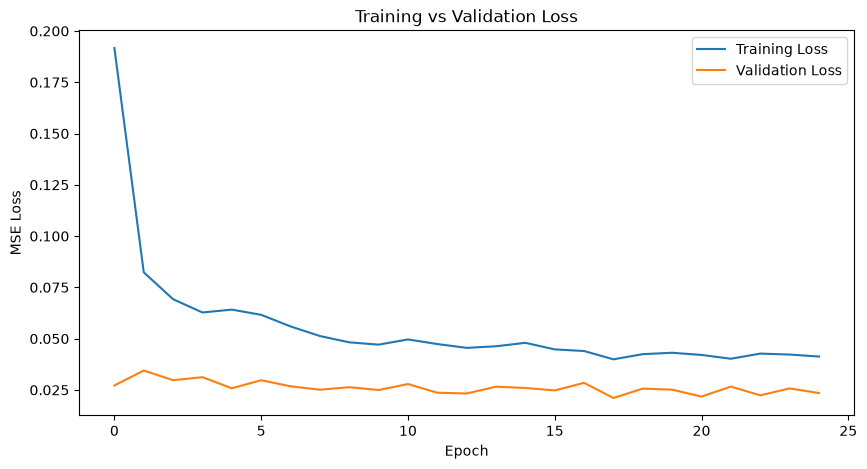

In [60]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()